In [2]:
from src import *

In [3]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'

width = 8.5 / 2.54 #inches

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

In [4]:
spade_mean, spade_var, spade_b = [], [], []
di_mean, di_var, di_b = [], [], []
for d in np.arange(0, 101, 2):
    spade_c = LoadEstimates(rf'data/noisy/spade_5px_f0.2_d{d}.npz')
    di_c = LoadEstimates(rf'data/noisy/di_5px_f0.2_d{d}.npz')

    spade_mean.append(spade_c.estimates.mean())
    spade_var.append(spade_c.estimates.var(ddof=1) * spade_c.photons)
    spade_b.append(spade_c.background / spade_c.photons)

    di_mean.append(di_c.estimates.mean())
    di_var.append(di_c.estimates.var(ddof=1) * di_c.photons)
    di_b.append(di_c.background / di_c.photons)

b_axis = np.linspace(1e-10, 0.2, 1000)
spade_crb = 1/SPADE.CFI(b_axis, DMD.A(5), 0.2)
di_crb = 1/DI.CFI(b_axis, DMD.A(5), 0.2)

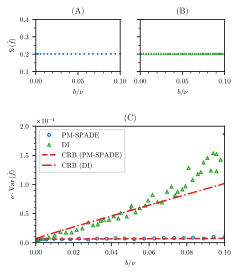

In [5]:
fig = plt.figure(figsize=(width, width*1.25))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax2.tick_params(axis='y', labelleft=False)

ax3 = fig.add_subplot(gs[1, :])

ax1.plot(spade_b, spade_mean, marker='o', linestyle='', markersize=1, 
         markeredgecolor=c1, markerfacecolor=c1)

ax2.plot(di_b, di_mean, marker='^', linestyle='', markersize=1, 
         markeredgecolor=c2, markerfacecolor=c2)

ax1.set_ylabel(r'${\rm \mathbb{S\,}}(\hat f)$')
ax3.set_ylabel(r'$\nu\cdot{\rm Var\,}(\hat f)$')

ax1.set_title('(A)')
ax2.set_title('(B)')
ax3.set_title('(C)')

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

for ax_ in (ax1, ax2, ax3):
    ax_.set_box_aspect(0.618)
    ax_.set_xlim(0, 0.1)
    ax_.set_xlabel(r'$b/\nu$')
    
    if ax_ == ax3:
        ax_.set_ylim(0, 2e-4)
        ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_.yaxis.set_minor_locator(AutoMinorLocator(5))
        ax_.set_xticks(np.linspace(0, 0.1, 6))
        ax_.set_yticks(np.arange(0, 2.001, 0.5) * 1e-4)
        ax_.yaxis.set_major_formatter(formatter)
  
    else:
        ax_.set_ylim(0.1, 0.4)
        ax_.set_xticks(np.linspace(0, 0.1, 3))
        ax_.set_yticks(np.linspace(0.1, 0.4, 4))
        ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_.yaxis.set_minor_locator(AutoMinorLocator(2))


ax3.plot(spade_b, spade_var, color=c1, marker='o', 
         linestyle='', markersize=3, 
         markeredgecolor=c1, markerfacecolor=(c1, 0.3),
         label='PM-SPADE')

ax3.plot(di_b, di_var, color=c2, marker='^', 
         linestyle='', markersize=3, 
         markeredgecolor=c2, markerfacecolor=(c2, 0.3),
         label='DI')

ax3.plot(b_axis, spade_crb, linestyle='--', color=red, label='CRB (PM-SPADE)')
ax3.plot(b_axis, di_crb, linestyle='-.', color=red, label='CRB (DI)')


ax3.legend(loc='best')
plt.tight_layout()
plt.savefig('noisy.pdf')
plt.show()
